# Bài 1: Titanic Dataset

### 0. Chuẩn bị môi trường

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

### 1. Tải dữ liệu

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 2. Tiền xử lí dữ liệu

In [3]:
# bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
df = df.drop(columns=leaky)

In [4]:
# chia train/val/test có stratify
X = df.drop(columns='survived')
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [5]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
X_test_t = preprocess.transform(X_test)

### 3. Dự đoán bằng Logistic Regression

In [6]:
log_model = LogisticRegression()
log_model.fit(X_train_t, y_train)
y_log_pred = log_model.predict(X_test_t)

### 4. Dự đoán bằng Linear Regression

In [7]:
ln_model = LinearRegression()
ln_model.fit(X_train_t, y_train)
y_ln_pred = ln_model.predict(X_test_t)
y_ln_pred_label = np.where(y_ln_pred >= 0.5, 1, 0)

### 5. Đánh giá kết quả dự đoán

In [8]:
def evaluate(y_true, y_pred):
    print(f"- Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"- Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"- Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"- F1-score: {f1_score(y_true, y_pred):.4f}")
    print("- Confusion matrix:\n", confusion_matrix(y_true, y_pred))

print("=== Logistic Regression ===")
evaluate(y_test, y_log_pred)

print("\n=== Linear Regression ===")
evaluate(y_test, y_ln_pred_label)

=== Logistic Regression ===
- Accuracy: 0.8045
- Precision: 0.7931
- Recall: 0.6667
- F1-score: 0.7244
- Confusion matrix:
 [[98 12]
 [23 46]]

=== Linear Regression ===
- Accuracy: 0.8101
- Precision: 0.7869
- Recall: 0.6957
- F1-score: 0.7385
- Confusion matrix:
 [[97 13]
 [21 48]]


### 6. So sánh 2 mô hình và kết luận

* Bản chất bài toán: Dự đoán khả năng sống sót của hành khách là bài toán phân loại nhị phân.
* Linear Regression:
    * Ép dữ liệu nhãn rời rạc thành một đường thẳng tuyến tính.
    * Đầu ra là giá trị liên tục từ $-\infty$ đến $+\infty$, có thể gây ra kết quả vô lý (ví dụ: xác suất sống sót là -0.5 hoặc 1.2).
    * Có thể bị lệch nghiêm trọng nếu có outlier.
* Logistic Regression:
    * Sử dụng hàm Sigmoid để nén kết quả thành dạng đường cong chữ S, fit dữ liệu tốt hơn.
    * Đầu ra là xác suất nằm trong khoảng [0, 1], phù hợp với bản chất bài toán.
    * Ranh giới quyết định tự nhiên, ổn định, không dễ bị kéo đi bởi outlier.

**Kết luận**: Logistic Regression là lựa chọn phù hợp hơn cho bài toán này.

# Bài 2: Dry Bean Dataset

### 0. Chuẩn bị môi trường

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

### 1. Tải dữ liệu

In [10]:
train_path = "Dry_Bean_Dataset/dry_bean_train.csv"
test_path = "Dry_Bean_Dataset/dry_bean_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
train_df.head()

,area,perimeter,majoraxislength,minoraxislength,aspectration,eccentricity,convexarea,equivdiameter,extent,solidity,roundness,compactness,shapefactor1,shapefactor2,shapefactor3,shapefactor4,class
0,69471,1069.638,399.100245,225.005782,1.773733,0.825923,71088,297.410868,0.707386,0.977254,0.763027,0.745203,0.005745,0.001093,0.555328,0.985004,CALI
1,82877,1162.581,391.817013,270.836144,1.446694,0.722634,84171,324.841921,0.825986,0.984627,0.770544,0.829065,0.004728,0.001378,0.687349,0.994384,BARBUNYA
2,65042,1023.506,419.202858,198.962774,2.106941,0.880190,65748,287.774298,0.783403,0.989262,0.780231,0.686480,0.006445,0.000883,0.471255,0.992906,HOROZ
3,41315,758.920,287.438268,183.447580,1.566869,0.769858,41704,229.355383,0.791930,0.990672,0.901417,0.797929,0.006957,0.001740,0.636691,0.997611,SIRA
4,91088,1168.645,459.300729,253.950486,1.808623,0.833243,91799,340.553731,0.789051,0.992255,0.838119,0.741461,0.005042,0.000940,0.549765,0.994318,CALI


### 2. Tách biến mục tiêu và features

In [11]:
target = 'class'

X_train = train_df.drop(columns=target)
y_train = train_df[target]
X_test = test_df.drop(columns=target)
y_test = test_df[target]

### 3. Tiền xử lí dữ liệu

In [12]:
# Chuẩn hóa các biến số
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Mã hóa biến mục tiêu phân loại
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

### 4. Logistic regression

In [13]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)
y_log_pred = log_model.predict(X_test)

### 5. K-Nearest Neighbors – KNN

In [14]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_knn_pred = knn_model.predict(X_test)

### 6. Đánh giá kết quả mô hình

In [15]:
def evaluate(y_true, y_pred):
    print(f"- Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("- Classification report:\n", classification_report(y_true, y_pred))

In [16]:
print("=== Logistic regression ===")
evaluate(y_test, y_log_pred)

=== Logistic regression ===
- Accuracy: 0.9192
- Classification report:
               precision    recall  f1-score   support

           0       0.93      0.89      0.91       265
           1       1.00      1.00      1.00       104
           2       0.91      0.94      0.93       326
           3       0.93      0.91      0.92       709
           4       0.96      0.94      0.95       372
           5       0.93      0.94      0.94       406
           6       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



In [17]:
print("=== K-Nearest Neighbors (k = 5) ===")
evaluate(y_test, y_knn_pred)

=== K-Nearest Neighbors (k = 5) ===
- Accuracy: 0.9155
- Classification report:
               precision    recall  f1-score   support

           0       0.93      0.88      0.90       265
           1       1.00      1.00      1.00       104
           2       0.90      0.95      0.92       326
           3       0.92      0.91      0.91       709
           4       0.96      0.93      0.95       372
           5       0.95      0.94      0.94       406
           6       0.85      0.87      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



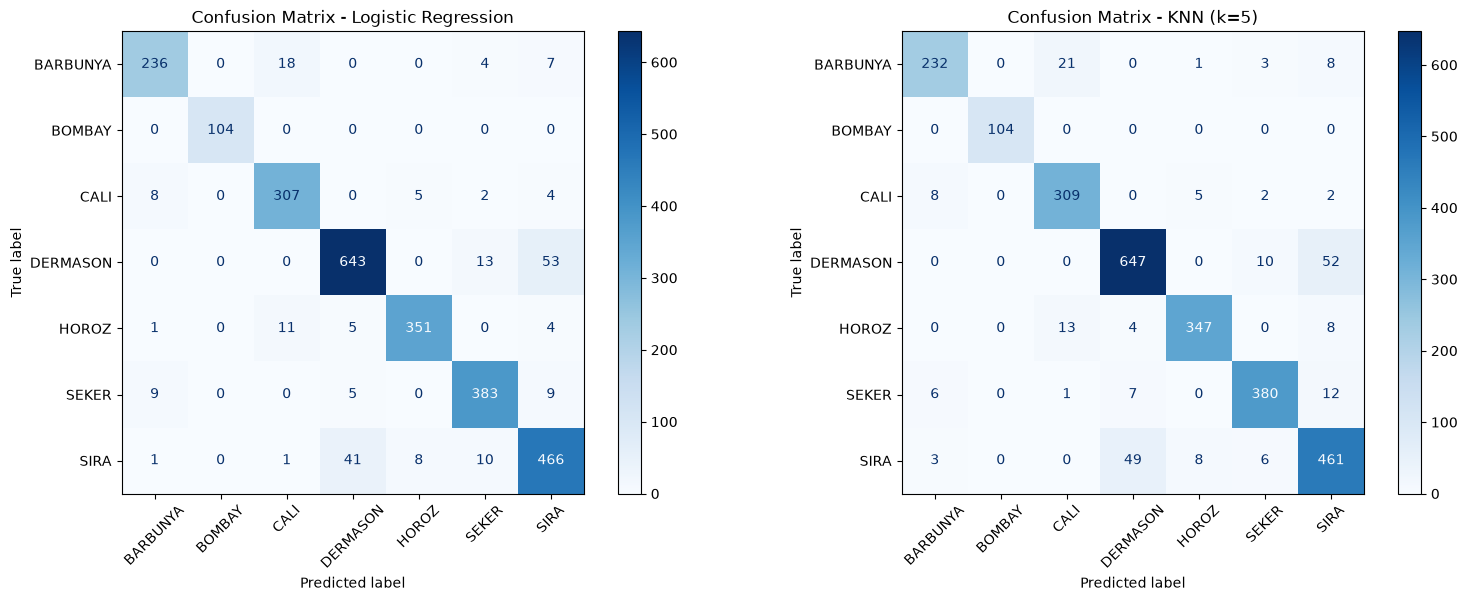

In [18]:
# Vẽ heatmap confusion matrix cho 2 mô hình
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_log_pred,
    display_labels=label_encoder.classes_,
    ax=axes[0], xticks_rotation=45, cmap='Blues'
)
axes[0].set_title("Confusion Matrix - Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_knn_pred,
    display_labels=label_encoder.classes_,
    ax=axes[1], xticks_rotation=45, cmap='Blues'
)
axes[1].set_title(f"Confusion Matrix - KNN (k=5)")

plt.tight_layout()
plt.show()

**Nhận xét:**
- Accuracy của 2 mô hình đều khá cao và không có sự chênh lệch đáng kể, Logistic Regression (91,92%) nhỉnh hơn KNN (91,55%) một chút.
- `BOMBAY` được phân loại tốt nhất (precision/recall = 1.00 ở cả 2 mô hình) --> là loại hạt có đặc trưng hình học rất khác biệt, dễ tách biệt với các loại còn lại.
- `SIRA` là nhóm khó phân loại nhất (có precision và recall thấp nhất), thường bị nhầm lẫn với `DERMASON` --> 2 loại có hình dạng/kích thước đặc trưng khá giống nhau, có thể cần bổ sung thêm đặc trưng để phân biệt.

### Kết luận:
Cả hai mô hình đều đạt hiệu suất khá tốt và tương đương nhau trên bộ dữ liệu này. Tuy nhiên, do không cần tính khoảng cách tới toàn bộ tập train khi predict như KNN nên Logistic Regression có tốc độ dự đoán nhanh hơn --> Logistic Regression là lựa chọn phù hợp cho bài toán.